# LastFM-1K User EDA
**User file:** `/project/pi_dagarwal_umass_edu/project_7/srikar/lastfm-dataset-1K/userid-profile.tsv`  
**Sessions file:** `user_sessions_lastfm1k_minuser1000_minitem7_sessgap1200_minsesslen10_minhist50.csv`

Goals:
- Count and profile users (demographics)
- Analyze listening activity volume and diversity
- Segment users by behavior: activity level, exploration breadth, session patterns
- Cluster and visualize user archetypes

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 13

PROFILE_PATH  = '/project/pi_dagarwal_umass_edu/project_7/srikar/lastfm-dataset-1K/userid-profile.tsv'
SESSIONS_PATH = '/work/pi_dagarwal_umass_edu/project_7/hmagapu/user_sessions_lastfm1k_minuser1000_minitem7_sessgap1200_minsesslen10_minhist50.csv'

print('Libraries loaded OK')

Libraries loaded OK


## 1. Load Data

In [2]:
# --- User profile ---
profile = pd.read_csv(PROFILE_PATH, sep='\t')
profile.rename(columns={'#id': 'user_id'}, inplace=True)
profile['registered'] = pd.to_datetime(profile['registered'], format='%b %d, %Y', errors='coerce')
profile['age'] = pd.to_numeric(profile['age'], errors='coerce')
print(f'User profiles: {profile.shape[0]:,} rows x {profile.shape[1]} cols')
profile.head(3)

User profiles: 992 rows x 5 cols


,user_id,gender,age,country,registered
0,user_000001,m,NaN,Japan,2006-08-13
1,user_000002,f,NaN,Peru,2006-02-24
2,user_000003,m,22.0,United States,2005-10-30


In [3]:
# --- Sessions (no header in file) ---
COL_NAMES = ['user_id', 'timestamp', 'artist_id', 'artist_name', 'track_id', 'track_name', 'session_id']
sessions = pd.read_csv(SESSIONS_PATH, header=None, names=COL_NAMES,
                       parse_dates=['timestamp'])
print(f'Session events: {sessions.shape[0]:,} rows x {sessions.shape[1]} cols')
sessions.head(3)

Session events: 4,213,960 rows x 7 cols


,user_id,timestamp,artist_id,artist_name,track_id,track_name,session_id
0,user_000001,2006-08-13 14:55:14,27613b78-1b9d-4ec3-9db5-fa0743465fdd,Herbie Hancock,8e81302a-6cde-4818-8703-43b5356ce0a0,The Essence,2
1,user_000001,2006-08-13 14:59:59,a74b1b7f-71a5-4011-9441-d0b5e4122711,Radiohead,1c0377bb-c00b-4bbe-b4b2-615f13324adc,Idioteque,2
2,user_000001,2006-08-13 15:05:20,477d1c52-3100-4493-a049-473d8f183e23,高木正勝,8f916d23-0510-4ad5-9a7f-8a076c3f14ca,Change Of Seasons,2


## 2. Data Quality & Completeness

In [4]:
print('=== Profile missing values ===')
missing = profile.isnull().sum()
pct = (missing / len(profile) * 100).round(1)
display(pd.DataFrame({'missing': missing, 'pct %': pct}))

print('\n=== Sessions missing values ===')
smiss = sessions.isnull().sum()
spct  = (smiss / len(sessions) * 100).round(2)
display(pd.DataFrame({'missing': smiss, 'pct %': spct}))

=== Profile missing values ===


,missing,pct %
user_id,0,0.0
gender,108,10.9
age,706,71.2
country,85,8.6
registered,8,0.8



=== Sessions missing values ===


,missing,pct %
user_id,0,0.0
timestamp,0,0.0
artist_id,0,0.0
artist_name,0,0.0
track_id,0,0.0
track_name,59,0.0
session_id,0,0.0


## 3. User Count Overview

In [5]:
total_profile_users  = profile['user_id'].nunique()
total_session_users  = sessions['user_id'].nunique()
overlap              = len(set(profile['user_id']) & set(sessions['user_id']))

print(f'Users in profile file  : {total_profile_users:>6,}')
print(f'Users in sessions file : {total_session_users:>6,}')
print(f'Overlap (both sources) : {overlap:>6,}')
print(f'Total events in dataset: {len(sessions):>10,}')

Users in profile file  :    992
Users in sessions file :    814
Overlap (both sources) :    814
Total events in dataset:  4,213,960


## 4. Demographics

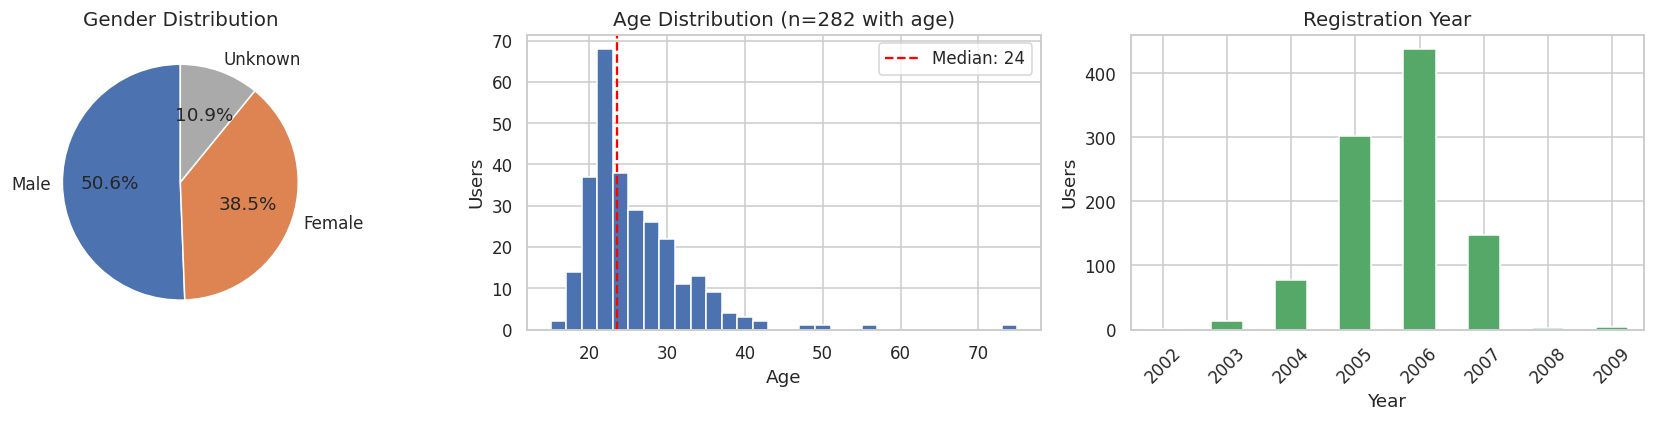

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 4a. Gender
gender_counts = profile['gender'].fillna('unknown').value_counts()
gender_labels = {'m': 'Male', 'f': 'Female', 'unknown': 'Unknown'}
gender_counts.index = [gender_labels.get(g, g) for g in gender_counts.index]
axes[0].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
            colors=['#4C72B0', '#DD8452', '#aaaaaa'], startangle=90)
axes[0].set_title('Gender Distribution')

# 4b. Age (filter plausible values)
age_valid = profile['age'].dropna()
age_valid = age_valid[(age_valid >= 13) & (age_valid <= 80)]
axes[1].hist(age_valid, bins=30, color='#4C72B0', edgecolor='white')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Users')
axes[1].set_title(f'Age Distribution (n={len(age_valid):,} with age)')
axes[1].axvline(age_valid.median(), color='red', ls='--', label=f'Median: {age_valid.median():.0f}')
axes[1].legend()

# 4c. Registration year
reg_year = profile['registered'].dt.year.dropna().astype(int)
reg_year.value_counts().sort_index().plot(kind='bar', ax=axes[2], color='#55A868', edgecolor='white')
axes[2].set_xlabel('Year')
axes[2].set_ylabel('Users')
axes[2].set_title('Registration Year')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

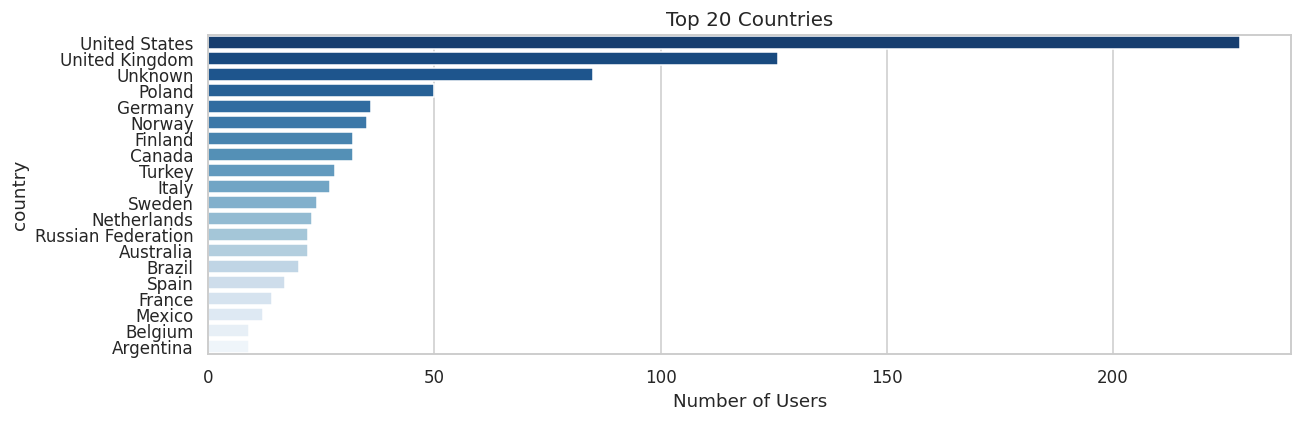

In [7]:
# Top countries
top_countries = profile['country'].fillna('Unknown').value_counts().head(20)
plt.figure(figsize=(12, 4))
sns.barplot(x=top_countries.values, y=top_countries.index, palette='Blues_r')
plt.xlabel('Number of Users')
plt.title('Top 20 Countries')
plt.tight_layout()
plt.show()

## 5. Per-User Listening Activity

In [8]:
user_stats = sessions.groupby('user_id').agg(
    total_plays       = ('track_name',  'count'),
    unique_tracks     = ('track_id',    'nunique'),
    unique_artists    = ('artist_id',   'nunique'),
    unique_sessions   = ('session_id',  'nunique'),
    first_listen      = ('timestamp',   'min'),
    last_listen       = ('timestamp',   'max'),
).reset_index()

user_stats['active_days'] = (user_stats['last_listen'] - user_stats['first_listen']).dt.days + 1
user_stats['plays_per_session'] = (user_stats['total_plays'] / user_stats['unique_sessions']).round(2)
user_stats['track_diversity'] = user_stats['unique_tracks'] / user_stats['total_plays']  # exact ratio; 1.0 = zero replays

print(f'Users with session data: {len(user_stats):,}')
user_stats.describe().round(1)

Users with session data: 814


,total_plays,unique_tracks,unique_artists,unique_sessions,first_listen,last_listen,active_days,plays_per_session,track_diversity
count,814.0,814.0,814.0,814.0,814,814,814.0,814.0,814.0
mean,5176.8,2094.3,441.2,517.7,2006-11-01 23:27:37.298525,2009-02-07 18:25:37.232186,829.3,10.0,0.5
min,500.0,157.0,20.0,50.0,2005-02-14 00:00:07,2005-10-29 20:59:11,20.0,9.9,0.1
25%,1632.5,857.5,202.2,163.2,2005-12-13 16:29:51.750000,2009-03-27 01:00:26.250000,462.0,10.0,0.3
50%,3505.0,1571.5,328.0,350.5,2006-08-19 14:54:16.500000,2009-04-28 13:52:27,871.0,10.0,0.5
75%,6960.0,2789.5,567.8,696.0,2007-09-15 21:14:24,2009-05-02 13:14:37.250000,1171.0,10.0,0.6
max,41110.0,18535.0,2735.0,4111.0,2009-04-19 17:46:18,2009-06-19 19:48:39,1586.0,10.0,1.0
std,4991.3,1787.5,357.1,499.1,NaN,NaN,431.1,0.0,0.2


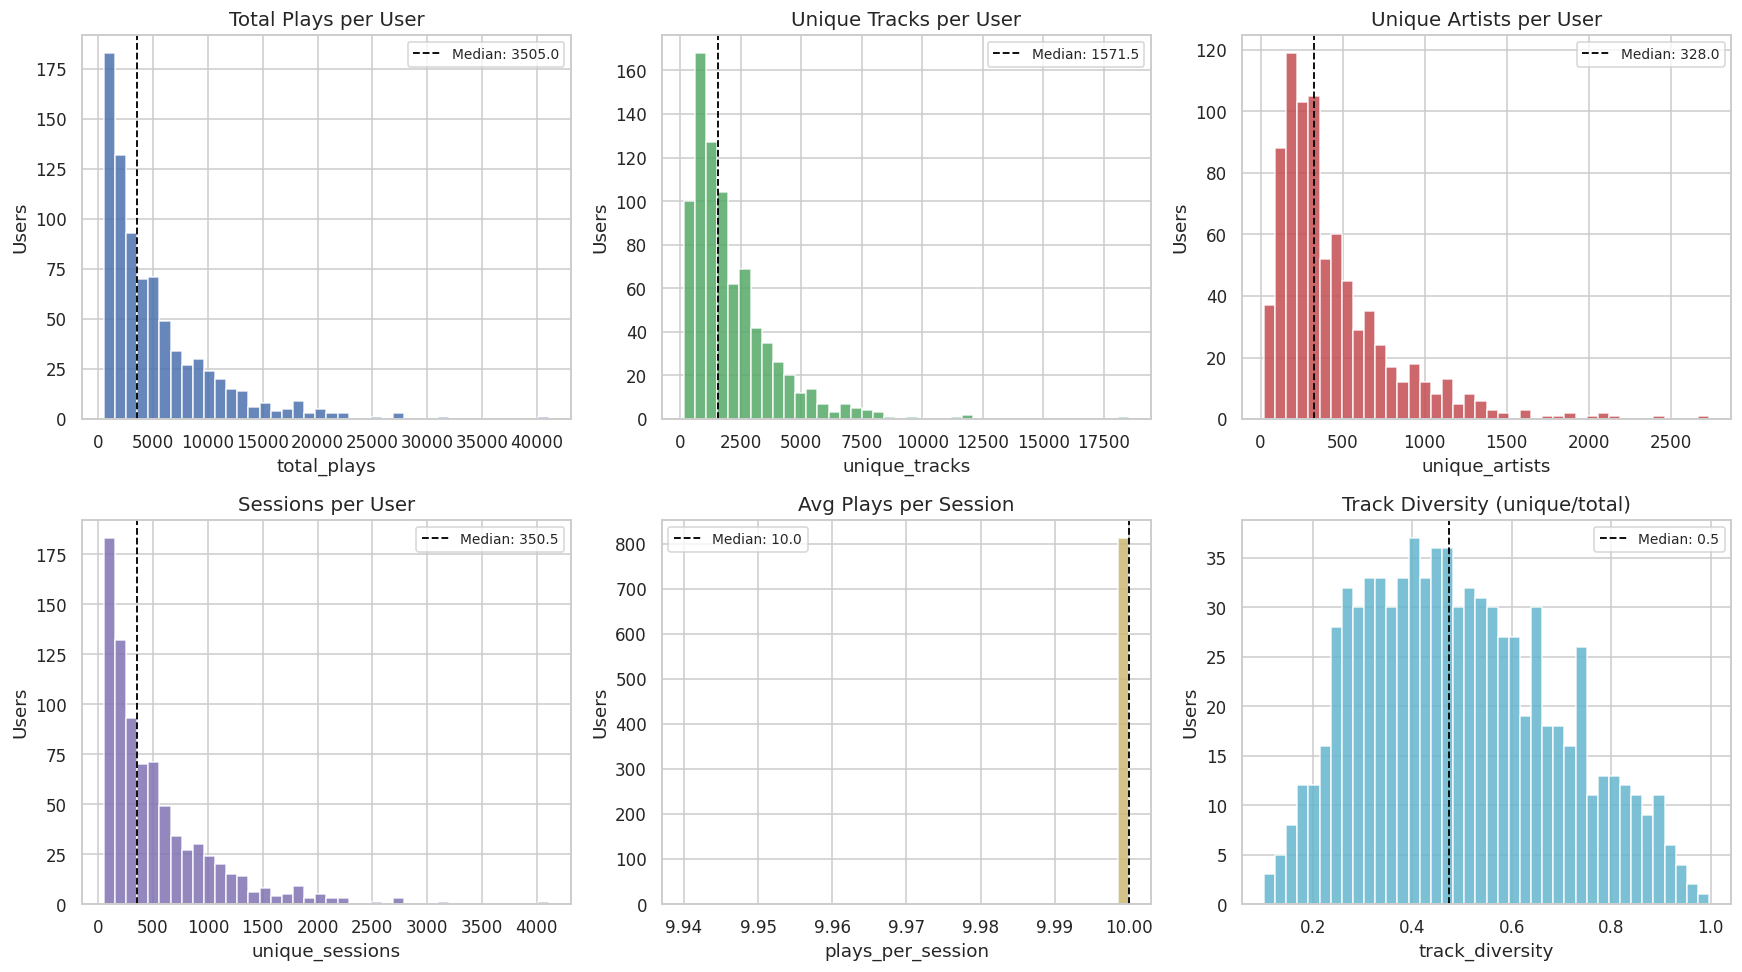

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

metrics = [
    ('total_plays',      'Total Plays per User',       '#4C72B0'),
    ('unique_tracks',    'Unique Tracks per User',     '#55A868'),
    ('unique_artists',   'Unique Artists per User',    '#C44E52'),
    ('unique_sessions',  'Sessions per User',          '#8172B2'),
    ('plays_per_session','Avg Plays per Session',      '#CCB974'),
    ('track_diversity',  'Track Diversity (unique/total)', '#64B5CD'),
]

for ax, (col, title, color) in zip(axes, metrics):
    data = user_stats[col].dropna()
    ax.hist(data, bins=40, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(data.median(), color='black', ls='--', lw=1.2, label=f'Median: {data.median():.1f}')
    ax.set_title(title)
    ax.set_xlabel(col)
    ax.set_ylabel('Users')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

### 5b. Song Replay Analysis
`track_diversity = unique_tracks / total_plays`  
A value of **1.0** means every play was a different song (zero replays).  
Lower values → more replaying. Here we quantify that directly.

In [10]:
# --- Replay metrics per user ---
user_stats['replay_plays']   = (user_stats['total_plays'] - user_stats['unique_tracks']).fillna(0).astype(int)
user_stats['replay_rate']    = (user_stats['replay_plays'] / user_stats['total_plays']).round(4)
user_stats['replays_any']    = user_stats['replay_plays'] > 0   # False = perfect diversity (every play is new)

n_replay     = user_stats['replays_any'].sum()
n_no_replay  = (~user_stats['replays_any']).sum()
pct_replay   = n_replay / len(user_stats) * 100
median_rate  = user_stats['replay_rate'].median() * 100
mean_rate    = user_stats['replay_rate'].mean()   * 100

print(f'Users who replay at least one song : {n_replay:,} / {len(user_stats):,}  ({pct_replay:.1f}%)')
print(f'Users with zero replays (diversity=1.0): {n_no_replay:,} / {len(user_stats):,}  ({100-pct_replay:.1f}%)')
print(f'Median replay rate (across users)  : {median_rate:.1f}%  of plays are re-plays')
print(f'Mean   replay rate (across users)  : {mean_rate:.1f}%')
print()
print('Replay-rate percentiles (% of plays that are replays):')
for p in [10, 25, 50, 75, 90, 95, 99]:
    print(f'  p{p:>2}: {user_stats["replay_rate"].quantile(p/100)*100:.1f}%')

Users who replay at least one song : 814 / 814  (100.0%)
Users with zero replays (diversity=1.0): 0 / 814  (0.0%)
Median replay rate (across users)  : 52.7%  of plays are re-plays
Mean   replay rate (across users)  : 50.5%

Replay-rate percentiles (% of plays that are replays):
  p10: 22.7%
  p25: 37.0%
  p50: 52.7%
  p75: 65.8%
  p90: 74.5%
  p95: 78.4%
  p99: 84.9%


In [ ]:
#why is max track_diversity 1.0 if 100% users replay at least one song? Does that user replay all songs?

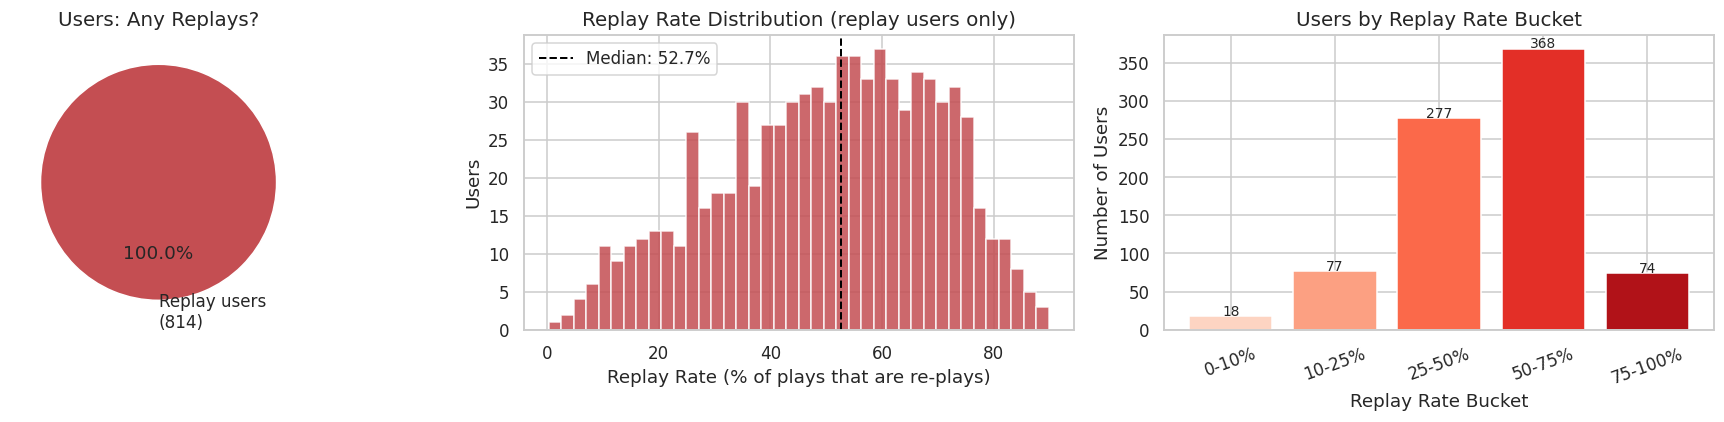

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))

# 1. How many users replay vs. don't
replay_counts = user_stats['replays_any'].value_counts().reindex([True, False], fill_value=0)
n_yes, n_no = int(replay_counts[True]), int(replay_counts[False])
pie_values  = [v for v in [n_yes, n_no] if v > 0]
pie_labels  = [lbl for lbl, v in
               [(f'Replay users\n({n_yes:,})', n_yes), (f'No-replay users\n({n_no:,})', n_no)]
               if v > 0]
pie_colors  = [c for c, v in [('#C44E52', n_yes), ('#55A868', n_no)] if v > 0]
axes[0].pie(pie_values, labels=pie_labels, autopct='%1.1f%%',
            colors=pie_colors, startangle=90)
axes[0].set_title('Users: Any Replays?')

# 2. Distribution of replay rate (replay users only)
replayers = user_stats[user_stats['replays_any']]['replay_rate'] * 100
axes[1].hist(replayers, bins=40, color='#C44E52', edgecolor='white', alpha=0.85)
axes[1].axvline(replayers.median(), color='black', ls='--', lw=1.3,
                label=f'Median: {replayers.median():.1f}%')
axes[1].set_xlabel('Replay Rate (% of plays that are re-plays)')
axes[1].set_ylabel('Users')
axes[1].set_title('Replay Rate Distribution (replay users only)')
axes[1].legend()

# 3. Replay rate buckets
bins   = [0, 0.10, 0.25, 0.50, 0.75, 1.01]
labels = ['0-10%', '10-25%', '25-50%', '50-75%', '75-100%']
user_stats['replay_bucket'] = pd.cut(user_stats['replay_rate'], bins=bins,
                                      labels=labels, right=False)
bucket_counts = user_stats['replay_bucket'].value_counts().reindex(labels)
bars = axes[2].bar(labels, bucket_counts.values,
                   color=sns.color_palette('Reds', len(labels)), edgecolor='white')
axes[2].set_xlabel('Replay Rate Bucket')
axes[2].set_ylabel('Number of Users')
axes[2].set_title('Users by Replay Rate Bucket')
axes[2].tick_params(axis='x', rotation=20)
for bar, v in zip(bars, bucket_counts.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, v + 1, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

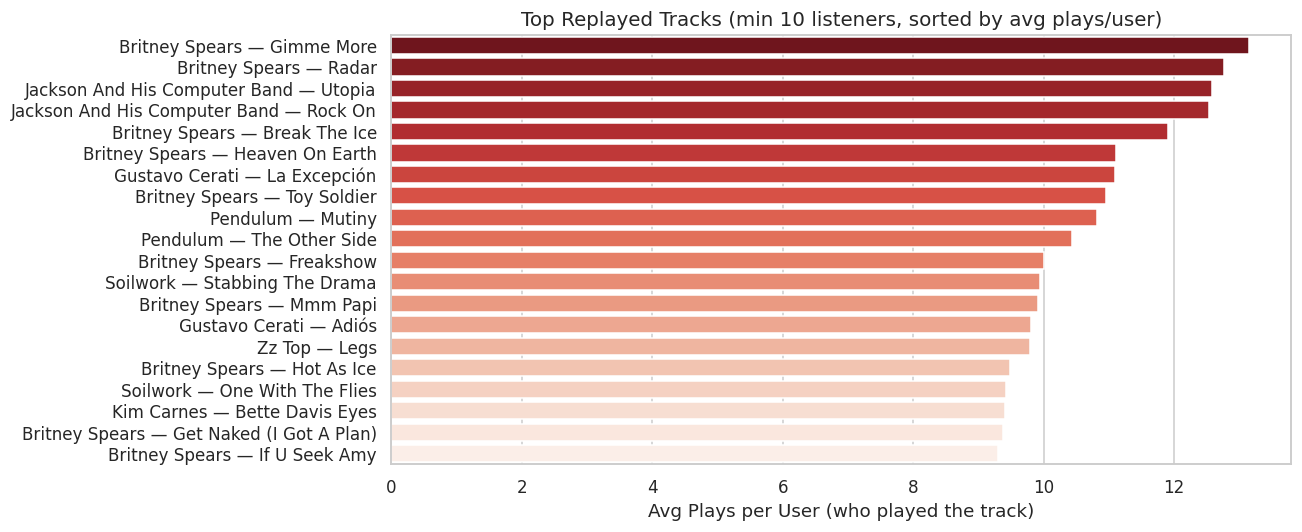

In [13]:
# Top 20 most-replayed tracks across all users
track_plays   = sessions.groupby(['track_id', 'artist_name', 'track_name'])['user_id'].count().rename('total_plays')
track_users   = sessions.groupby(['track_id', 'artist_name', 'track_name'])['user_id'].nunique().rename('unique_users')
track_df      = pd.concat([track_plays, track_users], axis=1).reset_index()
track_df['plays_per_user'] = (track_df['total_plays'] / track_df['unique_users']).round(2)

top_replayed = (track_df[track_df['unique_users'] >= 10]  # filter first, then rank
                .sort_values('plays_per_user', ascending=False)
                .head(20))

plt.figure(figsize=(12, 5))
labels_plot = top_replayed['artist_name'] + ' — ' + top_replayed['track_name']
sns.barplot(x=top_replayed['plays_per_user'].values, y=labels_plot.values, palette='Reds_r')
plt.xlabel('Avg Plays per User (who played the track)')
plt.title('Top Replayed Tracks (min 10 listeners, sorted by avg plays/user)')
plt.tight_layout()
plt.show()

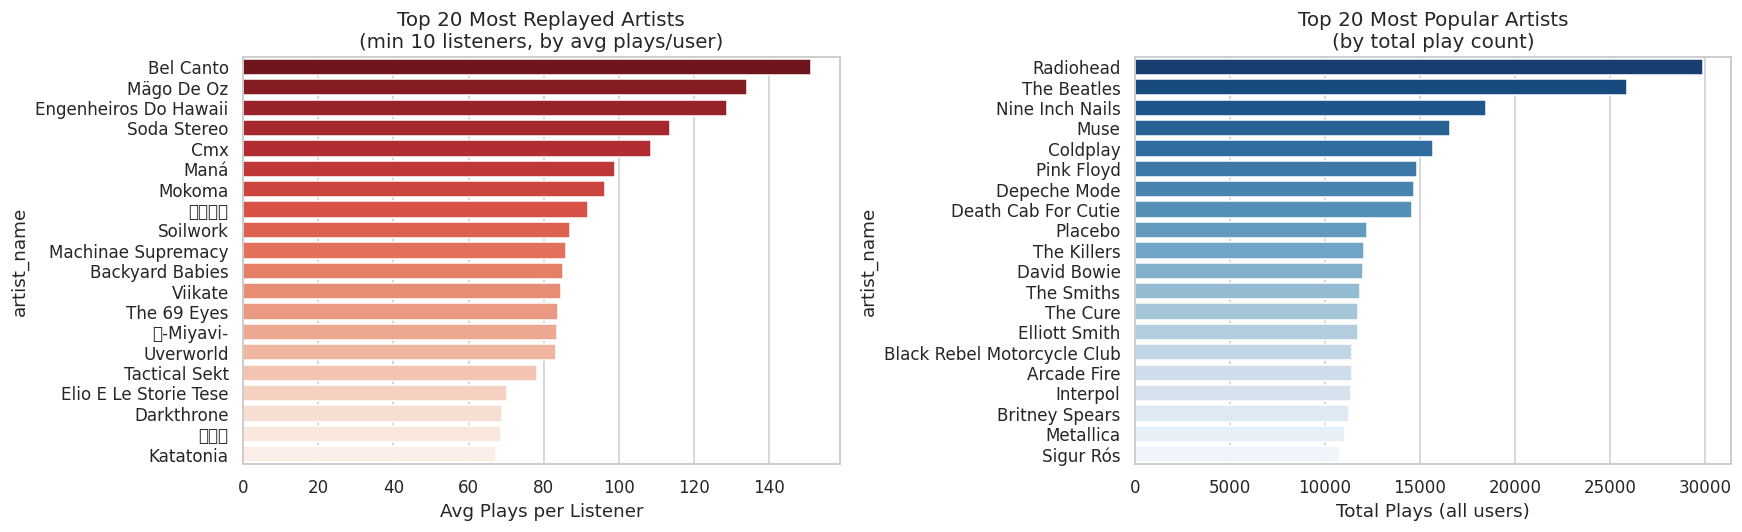


Note: "Replayed" ≠ "Popular" — compare left vs right to see the difference.


In [14]:
# Most replayed songs grouped by artist
# avg plays/user tells us which artists people obsessively re-listen to
artist_plays  = sessions.groupby(['artist_id', 'artist_name'])['user_id'].count().rename('total_plays')
artist_users  = sessions.groupby(['artist_id', 'artist_name'])['user_id'].nunique().rename('unique_users')
artist_df     = pd.concat([artist_plays, artist_users], axis=1).reset_index()
artist_df['plays_per_user'] = (artist_df['total_plays'] / artist_df['unique_users']).round(2)

top_artists_replay = (artist_df[artist_df['unique_users'] >= 10]
                      .sort_values('plays_per_user', ascending=False)
                      .head(20))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: most replayed artists (avg plays/user)
sns.barplot(x=top_artists_replay['plays_per_user'],
            y=top_artists_replay['artist_name'],
            palette='Reds_r', ax=axes[0])
axes[0].set_xlabel('Avg Plays per Listener')
axes[0].set_title('Top 20 Most Replayed Artists\n(min 10 listeners, by avg plays/user)')

# Right: most popular artists (absolute play count)
top_artists_pop = (artist_df[artist_df['unique_users'] >= 10]
                   .sort_values('total_plays', ascending=False)
                   .head(20))
sns.barplot(x=top_artists_pop['total_plays'],
            y=top_artists_pop['artist_name'],
            palette='Blues_r', ax=axes[1])
axes[1].set_xlabel('Total Plays (all users)')
axes[1].set_title('Top 20 Most Popular Artists\n(by total play count)')

plt.tight_layout()
plt.show()

print('\nNote: "Replayed" ≠ "Popular" — compare left vs right to see the difference.')

Britney Spears — 185 listeners in dataset


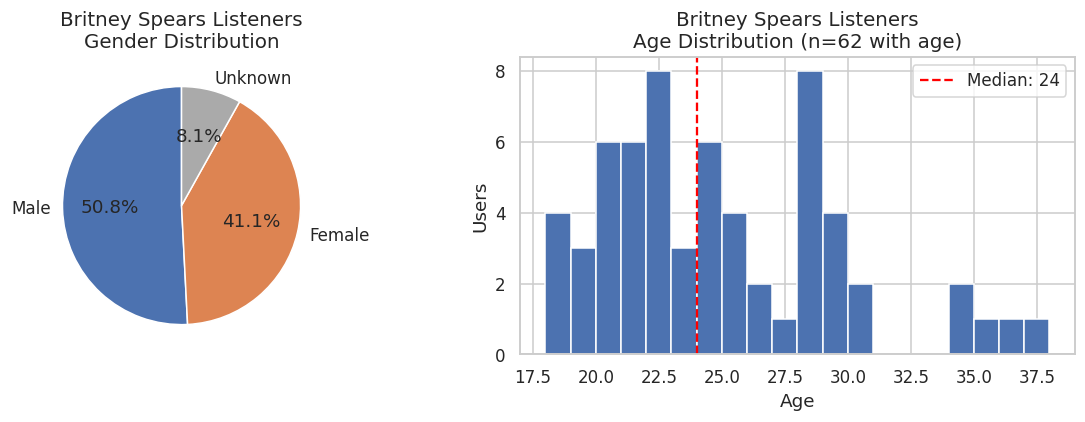

In [17]:
# Demographics of users who listen to a specific artist
# Change TARGET_ARTIST to explore any artist
TARGET_ARTIST = 'Britney Spears'

artist_sessions = sessions[sessions['artist_name'].str.lower() == TARGET_ARTIST.lower()]

if len(artist_sessions) == 0:
    matches = [a for a in sessions['artist_name'].dropna().unique()
               if TARGET_ARTIST.lower() in a.lower()]
    print(f'Exact match not found. Closest: {matches[:5]}')
else:
    listener_ids = artist_sessions['user_id'].unique()
    artist_demo  = profile[profile['user_id'].isin(listener_ids)].copy()
    artist_demo['gender_label'] = artist_demo['gender'].map({'m': 'Male', 'f': 'Female'}).fillna('Unknown')

    print(f'{TARGET_ARTIST} — {len(listener_ids):,} listeners in dataset')

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    # Gender pie
    gender_counts = artist_demo['gender_label'].value_counts()
    axes[0].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
                colors=['#4C72B0', '#DD8452', '#aaaaaa'], startangle=90)
    axes[0].set_title(f'{TARGET_ARTIST} Listeners\nGender Distribution')

    # Age histogram
    age_valid = artist_demo.dropna(subset=['age'])
    age_valid = age_valid[(age_valid['age'] >= 13) & (age_valid['age'] <= 80)]
    axes[1].hist(age_valid['age'], bins=20, color='#4C72B0', edgecolor='white')
    axes[1].axvline(age_valid['age'].median(), color='red', ls='--',
                    label=f"Median: {age_valid['age'].median():.0f}")
    axes[1].set_xlabel('Age')
    axes[1].set_ylabel('Users')
    axes[1].set_title(f'{TARGET_ARTIST} Listeners\nAge Distribution (n={len(age_valid):,} with age)')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

## 6. Activity Level Segmentation (Rule-Based)

In [18]:
# Quintile-based activity buckets on total_plays
q20, q40, q60, q80 = user_stats['total_plays'].quantile([0.20, 0.40, 0.60, 0.80])

def activity_label(p):
    if p <= q20: return '1-Casual'
    elif p <= q40: return '2-Light'
    elif p <= q60: return '3-Moderate'
    elif p <= q80: return '4-Active'
    else: return '5-Power'

user_stats['activity_level'] = user_stats['total_plays'].apply(activity_label)

print('Quintile thresholds (total plays):')
print(f'  Casual  : ≤ {q20:.0f}')
print(f'  Light   : ≤ {q40:.0f}')
print(f'  Moderate: ≤ {q60:.0f}')
print(f'  Active  : ≤ {q80:.0f}')
print(f'  Power   : > {q80:.0f}')
print()
print(user_stats['activity_level'].value_counts().sort_index())

Quintile thresholds (total plays):
  Casual  : ≤ 1370
  Light   : ≤ 2604
  Moderate: ≤ 4668
  Active  : ≤ 8312
  Power   : > 8312

activity_level
1-Casual      164
2-Light       162
3-Moderate    162
4-Active      163
5-Power       163
Name: count, dtype: int64


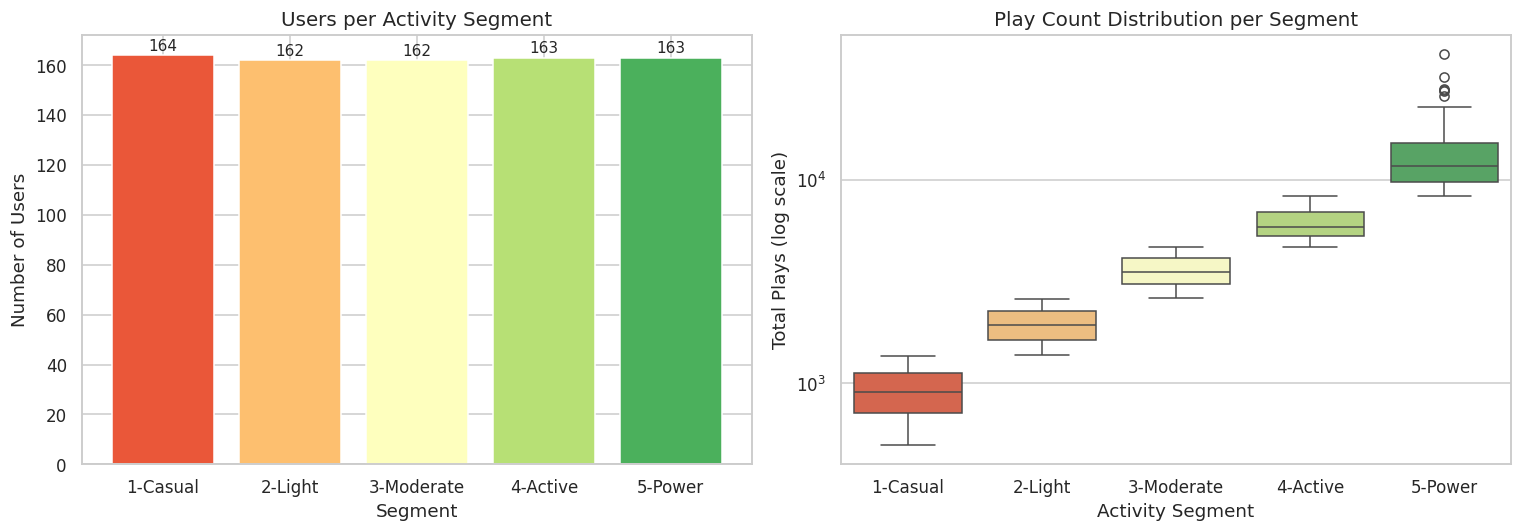

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = user_stats['activity_level'].value_counts().sort_index()
palette = sns.color_palette('RdYlGn', n_colors=5)
axes[0].bar(counts.index, counts.values, color=palette, edgecolor='white')
axes[0].set_title('Users per Activity Segment')
axes[0].set_xlabel('Segment')
axes[0].set_ylabel('Number of Users')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontsize=10)

sns.boxplot(data=user_stats, x='activity_level', y='total_plays',
            palette='RdYlGn', order=sorted(user_stats['activity_level'].unique()), ax=axes[1])
axes[1].set_title('Play Count Distribution per Segment')
axes[1].set_xlabel('Activity Segment')
axes[1].set_ylabel('Total Plays (log scale)')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

## 7. Explorer vs. Loyalist (Diversity Segmentation)

In [20]:
diversity_median = user_stats['track_diversity'].median()
artist_ratio_median = (user_stats['unique_artists'] / user_stats['unique_tracks']).median()

user_stats['artist_ratio'] = user_stats['unique_artists'] / user_stats['unique_tracks']

def diversity_label(row):
    hi_tracks  = row['track_diversity'] >= diversity_median
    hi_artists = row['artist_ratio']    >= artist_ratio_median
    if hi_tracks and hi_artists:  return 'Explorer'
    elif hi_tracks:               return 'Track Explorer'
    elif hi_artists:              return 'Artist Hopper'
    else:                         return 'Loyalist'

user_stats['diversity_type'] = user_stats.apply(diversity_label, axis=1)

print(user_stats['diversity_type'].value_counts())

diversity_type
Loyalist          245
Explorer          245
Track Explorer    162
Artist Hopper     162
Name: count, dtype: int64


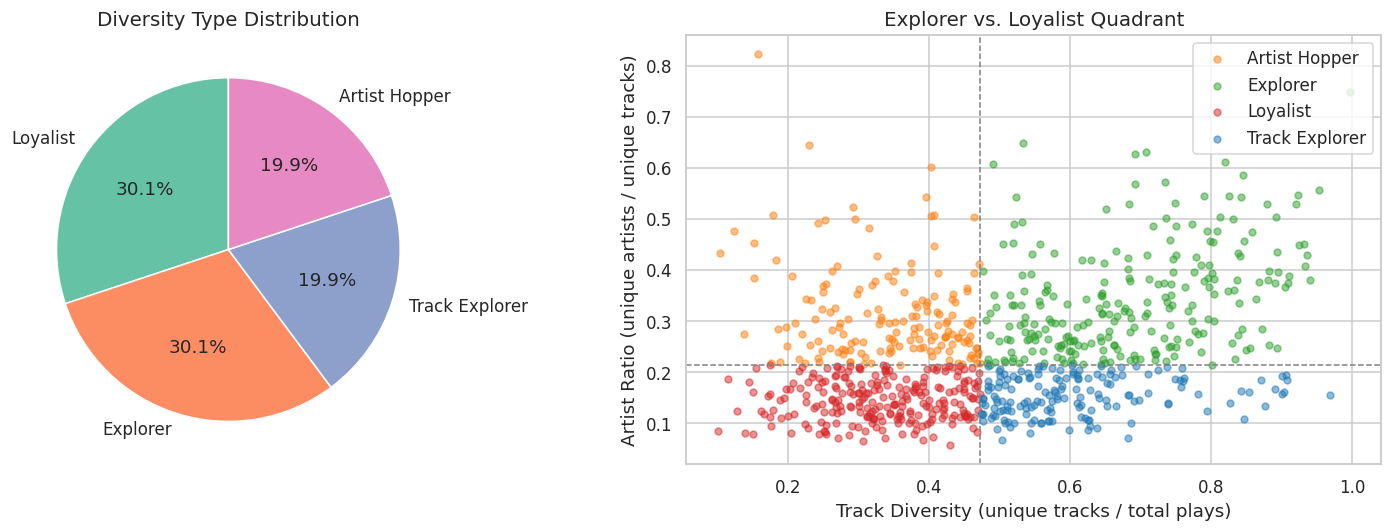

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dtype_counts = user_stats['diversity_type'].value_counts()
axes[0].pie(dtype_counts, labels=dtype_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('Set2', len(dtype_counts)), startangle=90)
axes[0].set_title('Diversity Type Distribution')

scatter_palette = {'Explorer': '#2ca02c', 'Track Explorer': '#1f77b4',
                   'Artist Hopper': '#ff7f0e', 'Loyalist': '#d62728'}
for dtype, grp in user_stats.groupby('diversity_type'):
    axes[1].scatter(grp['track_diversity'], grp['artist_ratio'],
                    label=dtype, alpha=0.5, s=20, color=scatter_palette.get(dtype))
axes[1].axvline(diversity_median, color='gray', ls='--', lw=1)
axes[1].axhline(artist_ratio_median, color='gray', ls='--', lw=1)
axes[1].set_xlabel('Track Diversity (unique tracks / total plays)')
axes[1].set_ylabel('Artist Ratio (unique artists / unique tracks)')
axes[1].set_title('Explorer vs. Loyalist Quadrant')
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Session Behavior Analysis

In [22]:
# --- Why does max(track_diversity) == 1.0 even though 100% of users replay? ---
# track_diversity was stored with .round(4), so a user with e.g.
# 9,999 unique tracks out of 10,000 plays  →  0.9999  →  rounds to 1.0000
# but still has 1 actual replay.  Let's prove it.

apparent_full = user_stats[user_stats['track_diversity'].round(4) == 1.0].copy()
apparent_full['exact_diversity'] = apparent_full['unique_tracks'] / apparent_full['total_plays']

cols = ['user_id', 'total_plays', 'unique_tracks', 'replay_plays',
        'track_diversity', 'exact_diversity']

print(f'Users whose track_diversity rounds to 1.0 : {len(apparent_full):,}')
print(f'  → truly zero replays (exact == 1.0)     : {(apparent_full["replay_plays"] == 0).sum():,}')
print(f'  → rounding artefact  (replay_plays > 0) : {(apparent_full["replay_plays"]  > 0).sum():,}')
print()
display(apparent_full[cols].sort_values('replay_plays'))

# Fix: store exact (unrounded) diversity going forward
user_stats['track_diversity'] = user_stats['unique_tracks'] / user_stats['total_plays']
print(f'\nAfter removing rounding  →  max track_diversity: {user_stats["track_diversity"].max()}')
print(f'Users with EXACT 0 replays : {(user_stats["replay_plays"] == 0).sum():,}')
print(f'Users with ≥ 1 replay      : {(user_stats["replay_plays"]  > 0).sum():,}')

Users whose track_diversity rounds to 1.0 : 0
  → truly zero replays (exact == 1.0)     : 0
  → rounding artefact  (replay_plays > 0) : 0



,user_id,total_plays,unique_tracks,replay_plays,track_diversity,exact_diversity



After removing rounding  →  max track_diversity: 0.996875
Users with EXACT 0 replays : 0
Users with ≥ 1 replay      : 814


In [23]:
session_stats = sessions.groupby(['user_id', 'session_id']).agg(
    session_plays  = ('track_name', 'count'),
    session_start  = ('timestamp',  'min'),
    session_end    = ('timestamp',  'max'),
).reset_index()

session_stats['session_duration_min'] = (
    (session_stats['session_end'] - session_stats['session_start']).dt.total_seconds() / 60
).round(1)

per_user_sessions = session_stats.groupby('user_id').agg(
    avg_session_length = ('session_plays',       'mean'),
    avg_session_dur_min= ('session_duration_min','mean'),
    total_sessions     = ('session_id',           'count'),
).reset_index()

user_stats = user_stats.merge(per_user_sessions, on='user_id', how='left')
print('Session stats computed.')
per_user_sessions.describe().round(1)

Session stats computed.


,avg_session_length,avg_session_dur_min,total_sessions
count,814.0,814.0,814.0
mean,10.0,45.1,517.7
std,0.0,6.6,499.1
min,9.9,27.2,50.0
25%,10.0,40.7,163.2
50%,10.0,44.0,350.5
75%,10.0,48.8,696.0
max,10.0,80.3,4111.0


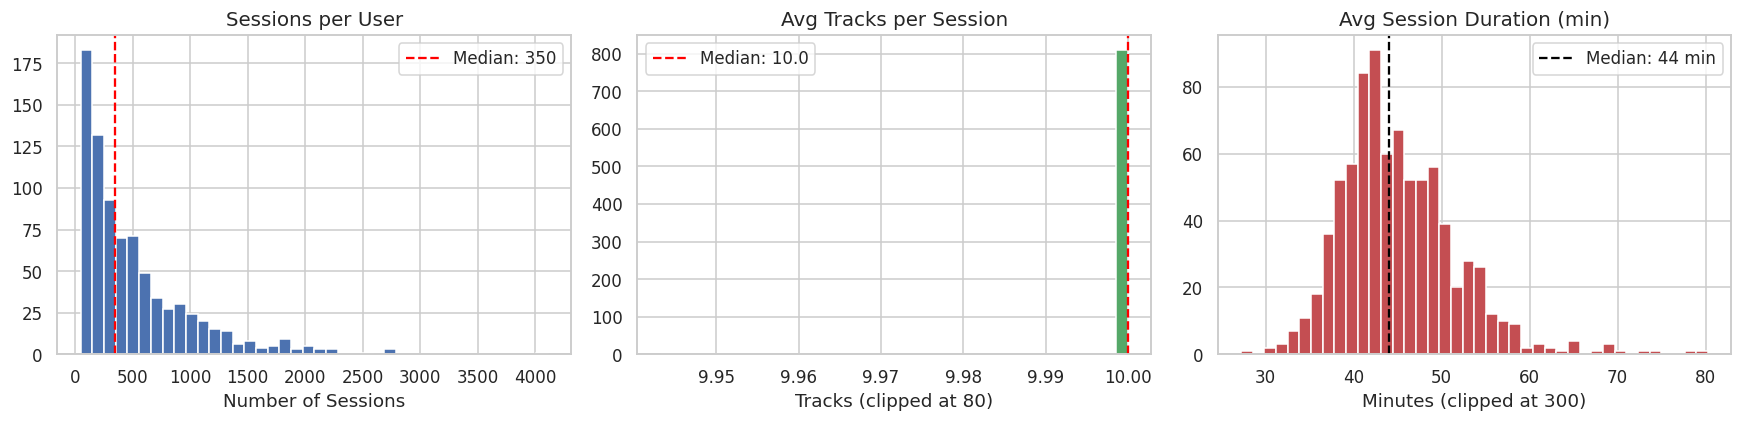

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(per_user_sessions['total_sessions'], bins=40, color='#4C72B0', edgecolor='white')
axes[0].set_title('Sessions per User')
axes[0].set_xlabel('Number of Sessions')
axes[0].axvline(per_user_sessions['total_sessions'].median(), color='red', ls='--',
                label=f"Median: {per_user_sessions['total_sessions'].median():.0f}")
axes[0].legend()

axes[1].hist(per_user_sessions['avg_session_length'].clip(upper=80), bins=40,
             color='#55A868', edgecolor='white')
axes[1].set_title('Avg Tracks per Session')
axes[1].set_xlabel('Tracks (clipped at 80)')
axes[1].axvline(per_user_sessions['avg_session_length'].median(), color='red', ls='--',
                label=f"Median: {per_user_sessions['avg_session_length'].median():.1f}")
axes[1].legend()

axes[2].hist(per_user_sessions['avg_session_dur_min'].clip(upper=300), bins=40,
             color='#C44E52', edgecolor='white')
axes[2].set_title('Avg Session Duration (min)')
axes[2].set_xlabel('Minutes (clipped at 300)')
axes[2].axvline(per_user_sessions['avg_session_dur_min'].median(), color='black', ls='--',
                label=f"Median: {per_user_sessions['avg_session_dur_min'].median():.0f} min")
axes[2].legend()

plt.tight_layout()
plt.show()

## 9. Temporal Patterns

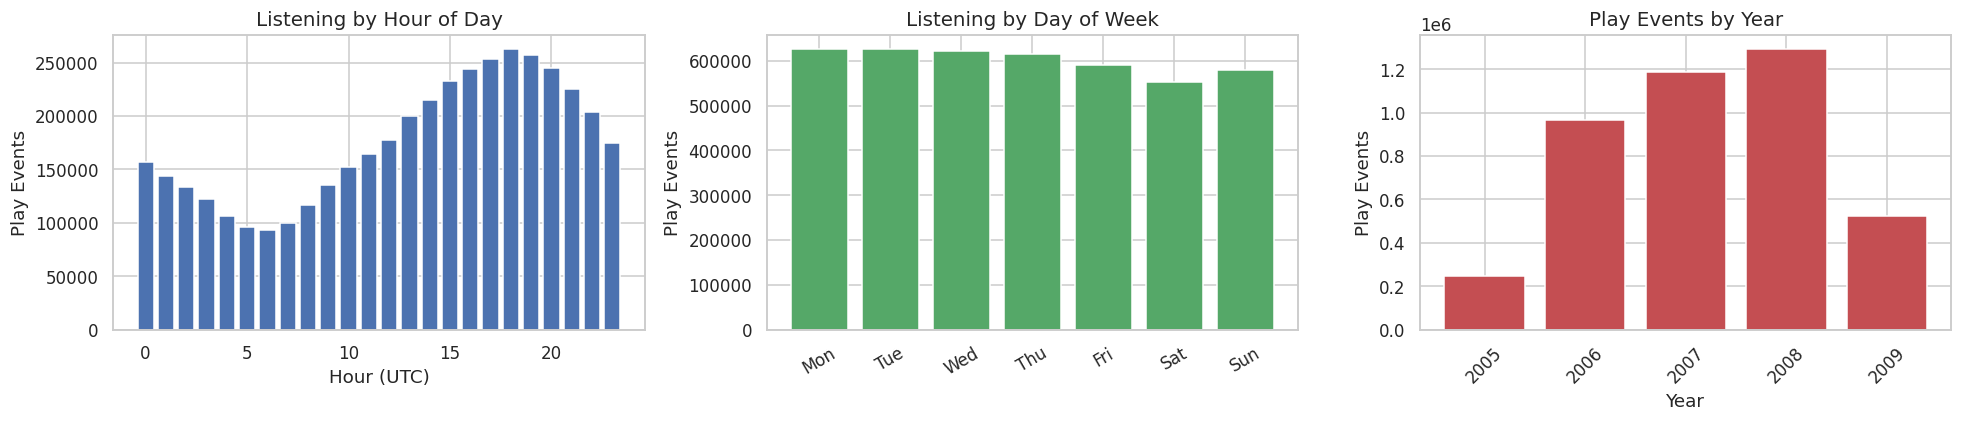

In [25]:
sessions['hour']       = sessions['timestamp'].dt.hour
sessions['dayofweek']  = sessions['timestamp'].dt.day_name()
sessions['year']       = sessions['timestamp'].dt.year

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Hour of day
hour_counts = sessions['hour'].value_counts().sort_index()
axes[0].bar(hour_counts.index, hour_counts.values, color='#4C72B0', edgecolor='white')
axes[0].set_title('Listening by Hour of Day')
axes[0].set_xlabel('Hour (UTC)')
axes[0].set_ylabel('Play Events')

# Day of week
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_counts = sessions['dayofweek'].value_counts().reindex(dow_order)
axes[1].bar(range(7), dow_counts.values, color='#55A868', edgecolor='white')
axes[1].set_xticks(range(7))
axes[1].set_xticklabels([d[:3] for d in dow_order], rotation=30)
axes[1].set_title('Listening by Day of Week')
axes[1].set_ylabel('Play Events')

# Year trend
year_counts = sessions['year'].value_counts().sort_index()
axes[2].bar(year_counts.index.astype(str), year_counts.values, color='#C44E52', edgecolor='white')
axes[2].set_title('Play Events by Year')
axes[2].set_xlabel('Year')
axes[2].set_ylabel('Play Events')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 10. K-Means Behavioral Clustering

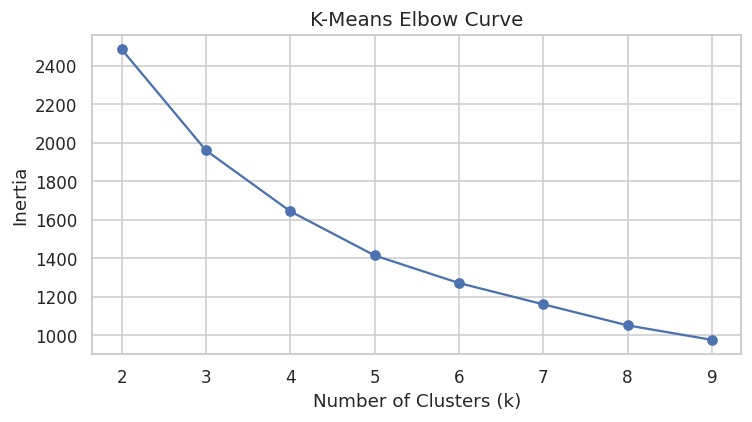

In [35]:
# Count-based features are right-skewed (power-law), so log-transform them
# before scaling.  Ratio features (track_diversity, artist_ratio) are already
# bounded [0,1] so they don't need it.
LOG_FEATURES   = ['total_plays', 'unique_tracks', 'unique_artists']
RATIO_FEATURES = ['track_diversity', 'artist_ratio']
FEATURES       = LOG_FEATURES + RATIO_FEATURES

cluster_df = user_stats[['user_id'] + FEATURES].dropna().copy()

# log1p(x) = log(x+1) so zero values don't blow up
cluster_df[LOG_FEATURES] = np.log1p(cluster_df[LOG_FEATURES])

X = cluster_df[FEATURES].values
X_scaled = StandardScaler().fit_transform(X)

# Elbow method
inertias = []
K_range = range(2, 10)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(K_range, inertias, 'o-', color='#4C72B0')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('K-Means Elbow Curve')
plt.tight_layout()
plt.show()

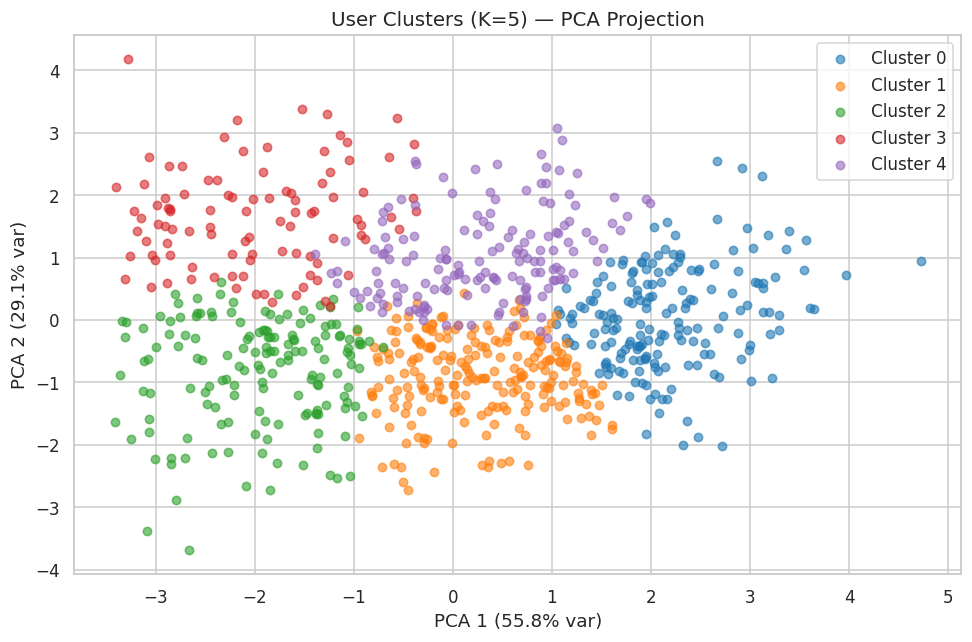

In [36]:
K = 5  # adjust based on elbow above
km = KMeans(n_clusters=K, random_state=42, n_init=10)
cluster_df['cluster'] = km.fit_predict(X_scaled)

# PCA for 2-D visualization
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)
cluster_df['pca1'] = coords[:, 0]
cluster_df['pca2'] = coords[:, 1]

plt.figure(figsize=(9, 6))
palette = sns.color_palette('tab10', K)
for c in range(K):
    mask = cluster_df['cluster'] == c
    plt.scatter(cluster_df.loc[mask, 'pca1'], cluster_df.loc[mask, 'pca2'],
                label=f'Cluster {c}', alpha=0.6, s=30, color=palette[c])
plt.xlabel(f'PCA 1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
plt.ylabel(f'PCA 2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
plt.title(f'User Clusters (K={K}) — PCA Projection')
plt.legend()
plt.tight_layout()
plt.show()

Cluster means (original scale, back-transformed from log):


,total_plays,unique_tracks,unique_artists,track_diversity,artist_ratio,size
cluster,,,,,,
0,11514.8,4047.6,696.8,0.4,0.2,182
1,4332.7,1494.8,246.6,0.4,0.2,219
2,1158.4,614.0,123.2,0.6,0.2,158
3,1097.9,748.3,336.2,0.7,0.5,98
4,3565.2,2157.2,576.5,0.6,0.3,157


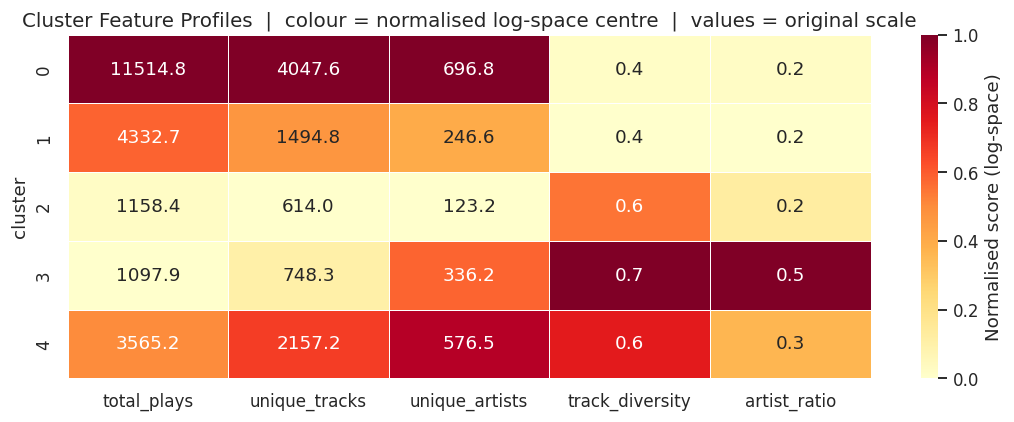

In [37]:
# Cluster profiles
# Cluster centres are in log-space; back-transform count features for display
cluster_profile_log = cluster_df.groupby('cluster')[FEATURES].mean()
cluster_profile_raw = cluster_profile_log.copy()
cluster_profile_raw[LOG_FEATURES] = np.expm1(cluster_profile_raw[LOG_FEATURES])  # inverse of log1p
cluster_profile_raw = cluster_profile_raw.round(1)
cluster_profile_raw['size'] = cluster_df['cluster'].value_counts().sort_index()

print('Cluster means (original scale, back-transformed from log):')
display(cluster_profile_raw)

# Heatmap: colour by normalised log-space centres, annotate with original-scale values
norm_profile = (cluster_profile_log[FEATURES] - cluster_profile_log[FEATURES].min()) / \
               (cluster_profile_log[FEATURES].max() - cluster_profile_log[FEATURES].min())

plt.figure(figsize=(10, 4))
sns.heatmap(norm_profile, annot=cluster_profile_raw[FEATURES], fmt='.1f',
            cmap='YlOrRd', linewidths=0.5, cbar_kws={'label': 'Normalised score (log-space)'})
plt.title('Cluster Feature Profiles  |  colour = normalised log-space centre  |  values = original scale')
plt.tight_layout()
plt.show()

In [34]:
# Assign human-readable archetype names based on cluster means
# (re-run / relabel after inspecting the heatmap above)
cp = cluster_profile_raw.copy()
cp['activity_rank']  = cp['total_plays'].rank()
cp['diversity_rank'] = cp['track_diversity'].rank()

def archetype(row):
    hi_a = row['activity_rank']  >= cp['activity_rank'].median()
    hi_d = row['diversity_rank'] >= cp['diversity_rank'].median()
    if hi_a and hi_d:   return 'Heavy Explorer'
    elif hi_a:          return 'Heavy Loyalist'
    elif hi_d:          return 'Casual Explorer'
    else:               return 'Casual Loyalist'

cp['archetype'] = cp.apply(archetype, axis=1)
archetype_map = cp['archetype'].to_dict()
cluster_df['archetype'] = cluster_df['cluster'].map(archetype_map)
user_stats = user_stats.merge(cluster_df[['user_id', 'cluster', 'archetype']], on='user_id', how='left')

print('Archetype mapping:')
print(cp[['archetype', 'total_plays', 'track_diversity', 'unique_artists', 'size']])

Archetype mapping:
               archetype  total_plays  track_diversity  unique_artists  size
cluster                                                                     
0        Casual Explorer       1054.8              0.7           321.4    95
1         Heavy Explorer       3699.1              0.6           619.4   150
2         Heavy Loyalist       4171.6              0.4           247.5   220
3         Heavy Loyalist      11631.6              0.4           677.0   186
4        Casual Explorer       1172.2              0.6           126.4   163


## 11. Combined Summary: Demographics × Behavior

In [ ]:
# Merge profile demographics with user_stats
combined = profile.merge(user_stats, on='user_id', how='inner')
combined['gender_label'] = combined['gender'].map({'m': 'Male', 'f': 'Female'}).fillna('Unknown')

print(f'Combined dataset: {len(combined):,} users')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plays by gender
sns.boxplot(data=combined[combined['gender_label'] != 'Unknown'],
            x='gender_label', y='total_plays', palette='Set2', ax=axes[0])
axes[0].set_yscale('log')
axes[0].set_title('Total Plays by Gender')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Total Plays (log)')

# Archetype counts by gender
archetype_gender = (combined[combined['gender_label'] != 'Unknown']
                    .groupby(['gender_label', 'archetype']).size().unstack(fill_value=0))
archetype_gender.plot(kind='bar', ax=axes[1], colormap='Set2', edgecolor='white')
axes[1].set_title('User Archetypes by Gender')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Users')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Archetype', bbox_to_anchor=(1.01, 1))

plt.tight_layout()
plt.show()

In [ ]:
# Age vs total plays coloured by archetype
age_plays = combined.dropna(subset=['age', 'archetype'])
age_plays = age_plays[(age_plays['age'] >= 13) & (age_plays['age'] <= 80)]

plt.figure(figsize=(9, 5))
for arch, grp in age_plays.groupby('archetype'):
    plt.scatter(grp['age'], grp['total_plays'], alpha=0.5, s=25, label=arch)
plt.yscale('log')
plt.xlabel('Age')
plt.ylabel('Total Plays (log)')
plt.title('Age vs. Listening Volume by Archetype')
plt.legend()
plt.tight_layout()
plt.show()

## 12. Final Summary Table

In [ ]:
summary_cols = ['total_plays', 'unique_tracks', 'unique_artists',
                'unique_sessions', 'avg_session_length', 'track_diversity']

summary = user_stats.groupby('archetype')[summary_cols].agg(['mean', 'median']).round(1)
summary.columns = ['_'.join(c) for c in summary.columns]
summary['n_users'] = user_stats['archetype'].value_counts()
display(summary)

print('\n=== Quick user count table ===')
count_table = pd.DataFrame({
    'Segment':   ['Total (profile)', 'Total (sessions)', 'Overlap'],
    'Count':     [total_profile_users, total_session_users, overlap]
})
display(count_table.set_index('Segment'))